## Current Cylinder Flow Fields
These cells load the current AMReX plotfiles in `out_re100_cyl/` and plot flow fields for the latest snapshot.

In [20]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import yt

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['image.cmap'] = 'viridis'


In [21]:
# Discover plotfiles (ignore *.old.* backups)
plot_dir = Path('out_cylinder')
if not plot_dir.exists():
    raise FileNotFoundError('Directory out_re100_cyl not found.')

pat = re.compile(r'^plt(\d+)$')
plotfiles = []
for d in plot_dir.iterdir():
    if not d.is_dir():
        continue
    m = pat.match(d.name)
    if m:
        plotfiles.append((int(m.group(1)), d))

if not plotfiles:
    raise RuntimeError('No plotfiles like pltNNNNN found in out_re100_cyl/.')

plotfiles.sort(key=lambda x: x[0])
print('Available plotfiles:', [d.name for _, d in plotfiles])
latest = plotfiles[-1][1]
earliest = plotfiles[0][1]
print('Using latest:', latest)


Available plotfiles: ['plt00000', 'plt00100', 'plt00200', 'plt00300', 'plt00320', 'plt00400', 'plt00500', 'plt00600', 'plt00700', 'plt00800', 'plt00900', 'plt01000', 'plt01100', 'plt01200', 'plt01300', 'plt01400', 'plt01500', 'plt01600', 'plt01700', 'plt01800', 'plt01900', 'plt02000', 'plt02100', 'plt02200', 'plt02300', 'plt02400', 'plt02500', 'plt02600', 'plt02700', 'plt02800', 'plt02900', 'plt03000', 'plt03100', 'plt03200', 'plt03300', 'plt03400', 'plt03500', 'plt03600', 'plt03700', 'plt03800', 'plt03900', 'plt04000', 'plt04100', 'plt04200', 'plt04300', 'plt04400', 'plt04500', 'plt04600', 'plt04700', 'plt04800', 'plt04900', 'plt05000', 'plt05100', 'plt05200', 'plt05300', 'plt05400', 'plt05500', 'plt05600', 'plt05700', 'plt05800', 'plt05900', 'plt06000', 'plt06100', 'plt06200', 'plt06300', 'plt06400', 'plt06500', 'plt06600', 'plt06700', 'plt06800', 'plt06900', 'plt07000', 'plt07100', 'plt07200', 'plt07300', 'plt07400', 'plt07500', 'plt07600', 'plt07700', 'plt07800', 'plt07900', 'plt08

In [22]:
# Load latest dataset
ds = yt.load(str(latest))
print('Dataset:', ds)
print('current_time:', ds.current_time)
print('domain_dimensions:', ds.domain_dimensions)
print('fields:', [f[1] for f in ds.field_list if f[0]=='boxlib'])


yt : [INFO     ] 2026-03-06 11:29:49,894 Parameters: current_time              = 12000.0
yt : [INFO     ] 2026-03-06 11:29:49,895 Parameters: domain_dimensions         = [512 256   1]
yt : [INFO     ] 2026-03-06 11:29:49,896 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-06 11:29:49,897 Parameters: domain_right_edge         = [512. 256.   1.]


Dataset: plt12000
current_time: 12000.0 code_time
domain_dimensions: [512 256   1]
fields: ['Pressure', 'f_new_0', 'f_new_1', 'f_new_2', 'f_new_3', 'f_new_4', 'f_new_5', 'f_new_6', 'f_new_7', 'f_new_8', 'phi', 'rho', 'ux', 'uy', 'uz', 'vor']


In [23]:
# Pull full level-0 grid for 2D plotting
dims = ds.domain_dimensions
cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=dims)

rho = np.array(cg[('boxlib', 'rho')])[:, :, 0]
ux  = np.array(cg[('boxlib', 'ux')])[:, :, 0]
uy  = np.array(cg[('boxlib', 'uy')])[:, :, 0]
vor = np.array(cg[('boxlib', 'vor')])[:, :, 0]
p   = np.array(cg[('boxlib', 'Pressure')])[:, :, 0]

x = np.linspace(float(ds.domain_left_edge[0]), float(ds.domain_right_edge[0]), rho.shape[0])
y = np.linspace(float(ds.domain_left_edge[1]), float(ds.domain_right_edge[1]), rho.shape[1])
X, Y = np.meshgrid(x, y, indexing='ij')

speed = np.sqrt(ux**2 + uy**2)
print('Shapes:', rho.shape, ux.shape, uy.shape, vor.shape)


Shapes: (512, 256) (512, 256) (512, 256) (512, 256)


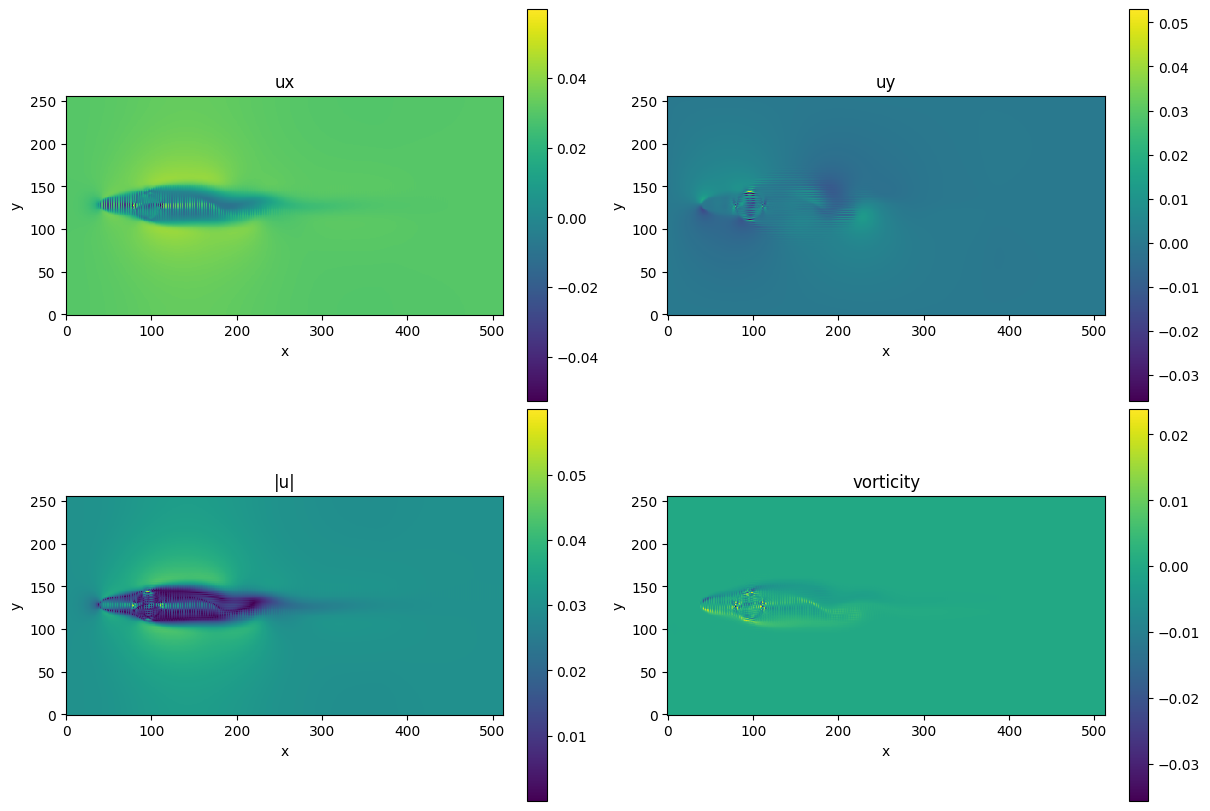

In [24]:
# Plot core flow fields
fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
im0 = ax[0,0].pcolormesh(X, Y, ux, shading='auto')
ax[0,0].set_title('ux')
fig.colorbar(im0, ax=ax[0,0])

im1 = ax[0,1].pcolormesh(X, Y, uy, shading='auto')
ax[0,1].set_title('uy')
fig.colorbar(im1, ax=ax[0,1])

im2 = ax[1,0].pcolormesh(X, Y, speed, shading='auto')
ax[1,0].set_title('|u|')
fig.colorbar(im2, ax=ax[1,0])

im3 = ax[1,1].pcolormesh(X, Y, vor, shading='auto')
ax[1,1].set_title('vorticity')
fig.colorbar(im3, ax=ax[1,1])

for a in ax.ravel():
    a.set_xlabel('x')
    a.set_ylabel('y')
    a.set_aspect('equal')
plt.show()


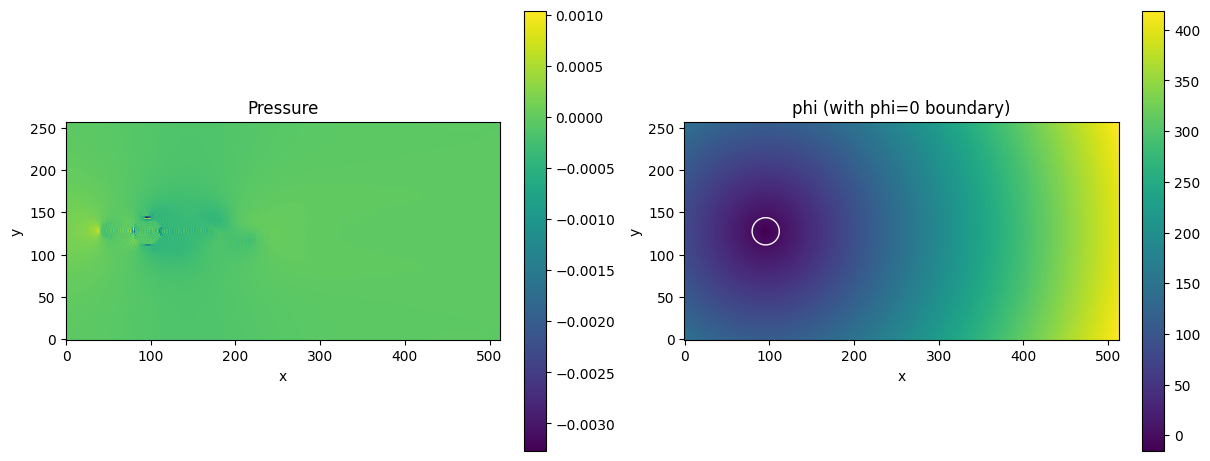

In [25]:
# Pressure and phi (immersed boundary indicator)
phi = np.array(cg[('boxlib', 'phi')])[:, :, 0]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, p, shading='auto')
ax[0].set_title('Pressure')
fig.colorbar(im0, ax=ax[0])

im1 = ax[1].pcolormesh(X, Y, phi, shading='auto')
ax[1].contour(X, Y, phi, levels=[0.0], colors='w', linewidths=1.0)
ax[1].set_title('phi (with phi=0 boundary)')
fig.colorbar(im1, ax=ax[1])

for a in ax:
    a.set_xlabel('x')
    a.set_ylabel('y')
    a.set_aspect('equal')
plt.show()


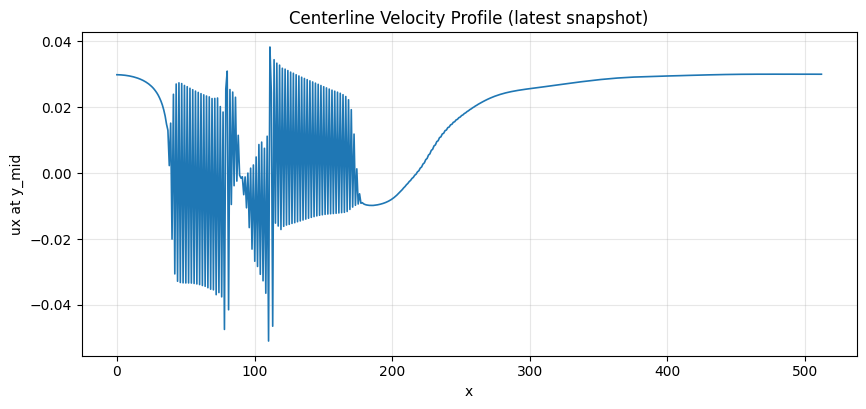

In [26]:
# Centerline profile: ux(x, y_mid)
jmid = ux.shape[1] // 2
plt.figure(figsize=(10, 4.2))
plt.plot(x, ux[:, jmid], lw=1.2)
plt.xlabel('x')
plt.ylabel('ux at y_mid')
plt.title('Centerline Velocity Profile (latest snapshot)')
plt.grid(alpha=0.3)
plt.show()


yt : [INFO     ] 2026-03-06 11:29:52,791 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-06 11:29:52,792 Parameters: domain_dimensions         = [512 256   1]
yt : [INFO     ] 2026-03-06 11:29:52,793 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-06 11:29:52,794 Parameters: domain_right_edge         = [512. 256.   1.]


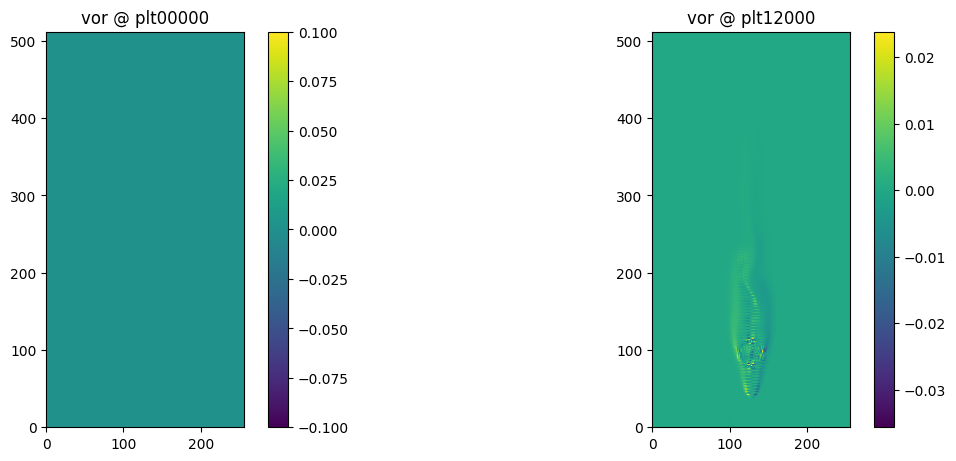

In [27]:
# Optional: compare earliest vs latest vorticity fields
if earliest != latest:
    ds0 = yt.load(str(earliest))
    cg0 = ds0.covering_grid(level=0, left_edge=ds0.domain_left_edge, dims=ds0.domain_dimensions)
    vor0 = np.array(cg0[('boxlib', 'vor')])[:, :, 0]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    im0 = ax[0].pcolormesh(vor0, shading='auto')
    ax[0].set_title(f'vor @ {earliest.name}')
    ax[0].set_aspect('equal')
    fig.colorbar(im0, ax=ax[0])

    im1 = ax[1].pcolormesh(vor, shading='auto')
    ax[1].set_title(f'vor @ {latest.name}')
    ax[1].set_aspect('equal')
    fig.colorbar(im1, ax=ax[1])
    plt.show()
else:
    print('Only one plotfile found; skipping earliest-vs-latest comparison.')


## Cylinder Force Visualization (Cd/Cl vs Time)
"
"This section reads `force.dat` (or a selected `_artifacts/force_*.dat`) and plots:
"
"- Cd vs time
"
"- Cl vs time
"
"- Tail-window zoom (last 30%)
"
"- Cl spectrum (FFT, low-St band)
"


In [28]:
from pathlib import Path
"
"import numpy as np
"
"import matplotlib.pyplot as plt

"
"# Pick file here (set force_file manually if desired)
"
"candidates = [
"
"    Path('force.dat'),
"
"    Path('_artifacts/force_re200_long_30k_check_partial.dat'),
"
"    Path('_artifacts/force_re200_clean_y127p5_12kplus.dat'),
"
"]
"
"force_file = next((p for p in candidates if p.exists()), None)
"
"if force_file is None:
"
"    raise FileNotFoundError('No force file found. Put force.dat in this folder or update `candidates`.')
"
"print('Using force file:', force_file)

"
"rows = []
"
"with force_file.open() as f:
"
"    for line in f:
"
"        s = line.strip()
"
"        if not s or s.startswith('#'):
"
"            continue
"
"        vals = s.split()
"
"        if len(vals) < 18:
"
"            continue
"
"        rows.append([float(v) for v in vals])

"
"A = np.array(rows)
"
"step = A[:, 0]
"
"t_lbm = A[:, 1]
"
"cd = A[:, 4]      # primary Cd
"
"cl = A[:, 5]      # primary Cl
"
"cd_me = A[:, 16]  # momentum-exchange Cd
"
"cl_me = A[:, 17]  # momentum-exchange Cl
"
"t_conv = A[:, 18] if A.shape[1] > 18 else None

"
"if t_conv is not None:
"
"    x = t_conv
"
"    xlabel = 'Convective time t* = tU0/D'
"
"else:
"
"    x = t_lbm
"
"    xlabel = 'Lattice time step'

"
"print('Samples:', len(A), 'step range:', int(step[0]), '->', int(step[-1]))
"


SyntaxError: unterminated string literal (detected at line 2) (3453908038.py, line 2)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
"
"ax[0].plot(x, cd_me, lw=1.0, label='Cd (ME)')
"
"ax[0].plot(x, cd, lw=0.9, alpha=0.5, label='Cd (primary)')
"
"ax[0].set_ylabel('Cd')
"
"ax[0].grid(alpha=0.3)
"
"ax[0].legend(loc='best')

"
"ax[1].plot(x, cl_me, lw=1.0, color='tab:orange', label='Cl (ME)')
"
"ax[1].plot(x, cl, lw=0.9, alpha=0.5, color='tab:green', label='Cl (primary)')
"
"ax[1].set_ylabel('Cl')
"
"ax[1].set_xlabel(xlabel)
"
"ax[1].grid(alpha=0.3)
"
"ax[1].legend(loc='best')

"
"fig.suptitle('Cylinder Force Coefficients vs Time', y=1.02)
"
"fig.tight_layout()
"
"plt.show()
"


In [ ]:
# Tail-window zoom (last 30%)
"
"i0 = int(0.7 * len(x))
"
"xt = x[i0:]
"
"cdt = cd_me[i0:]
"
"clt = cl_me[i0:]

"
"fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
"
"ax[0].plot(xt, cdt, lw=1.0)
"
"ax[0].set_ylabel('Cd (ME)')
"
"ax[0].grid(alpha=0.3)

"
"ax[1].plot(xt, clt, lw=1.0, color='tab:orange')
"
"ax[1].set_ylabel('Cl (ME)')
"
"ax[1].set_xlabel(xlabel)
"
"ax[1].grid(alpha=0.3)

"
"fig.suptitle('Tail Window (Last 30%)', y=1.02)
"
"fig.tight_layout()
"
"plt.show()
"


In [ ]:
# Simple FFT of Cl in low-Strouhal band
"
"u0 = 0.03
"
"D = 32.0

"
"cl_sig = cl_me - np.mean(cl_me)
"
"dt = (x[-1] - x[0]) / (len(x) - 1)
"
"freq = np.fft.rfftfreq(len(cl_sig), d=dt)
"
"amp = np.abs(np.fft.rfft(cl_sig))

"
"if t_conv is not None:
"
"    st = freq  # x-axis is already convective time
"
"else:
"
"    st = freq * D / u0

"
"mask = (st >= 0.05) & (st <= 0.5)
"
"if np.any(mask):
"
"    i = np.where(mask)[0][np.argmax(amp[mask])]
"
"    print(f'Dominant St in [0.05,0.5]: {st[i]:.6f}')

"
"plt.figure(figsize=(10, 4.5))
"
"plt.plot(st[mask], amp[mask], lw=1.0)
"
"plt.xlabel('Strouhal number St')
"
"plt.ylabel('|FFT(Cl)|')
"
"plt.title('Cl Spectrum (Low-St Band)')
"
"plt.grid(alpha=0.3)
"
"plt.tight_layout()
"
"plt.show()
"
